Error processing ._ninja_wind_35.1460_-90.0518_uncorrected (19).csv: 'utf-8' codec can't decode byte 0xb0 in position 37: invalid start byte
Error processing ._ninja_wind_35.1460_-90.0518_uncorrected (20).csv: 'utf-8' codec can't decode byte 0xb0 in position 37: invalid start byte


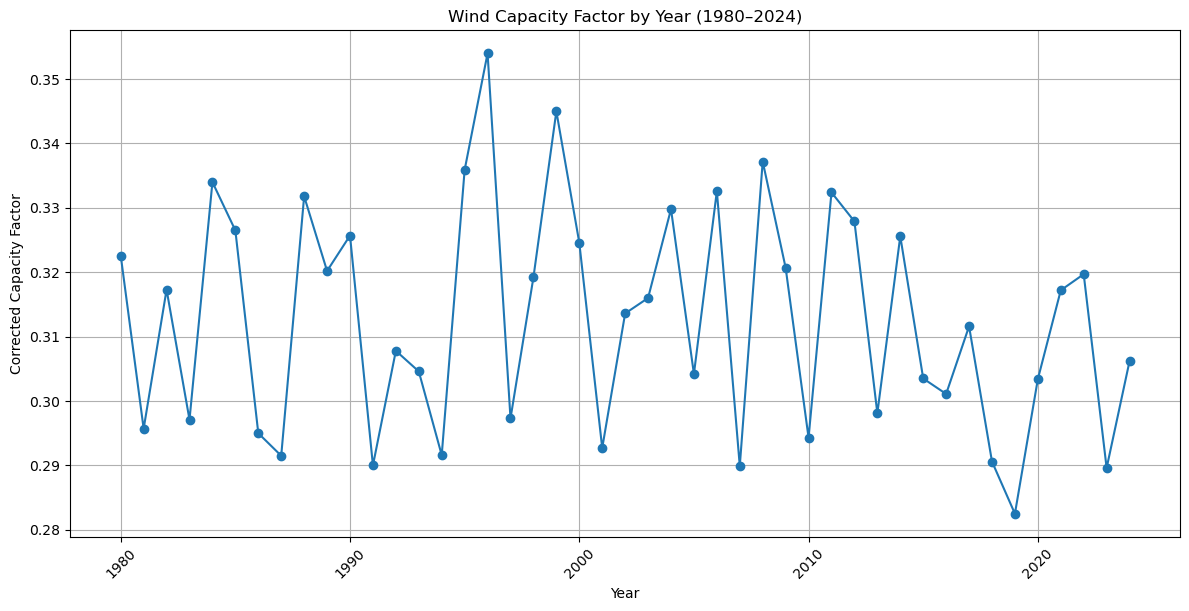


📈 Capacity Factor Vector (1980–2024):

[0.3226, 0.2957, 0.3173, 0.2971, 0.334, 0.3265, 0.295, 0.2915, 0.3318, 0.3202, 0.3257, 0.29, 0.3078, 0.3046, 0.2916, 0.3359, 0.354, 0.2973, 0.3192, 0.345, 0.3246, 0.2927, 0.3136, 0.316, 0.3298, 0.3042, 0.3326, 0.2899, 0.3372, 0.3207, 0.2943, 0.3324, 0.3279, 0.2981, 0.3256, 0.3035, 0.3011, 0.3116, 0.2906, 0.2825, 0.3034, 0.3172, 0.3197, 0.2896, 0.3062]


In [17]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# === CONFIGURATION ===
dir_1980s = 'Desktop/Wind/1900s/'  # Folder with files named like "ninja_pv (...)"
dir_2000s = 'Desktop/Wind/2000s/'  # Folder with files named like "ninja_pv (...)"
panel_max_output_kw = 1650         # Max Output of Vestas 1.65MW

def extract_cf_from_folder(data_dir, year_from_index_fn):
    cf_data = []
    for filename in sorted(os.listdir(data_dir)):
        if filename.endswith('.csv') and '(' in filename and ')' in filename:
            try:
                file_index = int(filename.split('(')[-1].split(')')[0])
                year = year_from_index_fn(file_index)

                path = os.path.join(data_dir, filename)
                df = pd.read_csv(path, skiprows=3)

                if 'electricity' not in df.columns:
                    print(f"Skipping {filename} (missing 'electricity' column)")
                    continue

                raw_mean_cf = df['electricity'].mean()
                corrected_cf = raw_mean_cf / panel_max_output_kw

                cf_data.append((year, round(corrected_cf, 4)))
            except Exception as e:
                print(f"Error processing {filename}: {e}")
    return cf_data

# === Extract CFs from both folders ===
cf_1980s = extract_cf_from_folder(dir_1980s, lambda idx: 1900 + idx)
cf_2000s = extract_cf_from_folder(dir_2000s, lambda idx: 2024 - idx)

# === Combine and sort ===
all_cf = cf_1980s + cf_2000s
all_cf_sorted = sorted(all_cf, key=lambda x: x[0])

# === Convert to DataFrame ===
df_cf = pd.DataFrame(all_cf_sorted, columns=['Year', 'Corrected_CF'])

# === Plot ===
plt.figure(figsize=(12, 6))
plt.plot(df_cf['Year'], df_cf['Corrected_CF'], marker='o')
plt.title('Wind Capacity Factor by Year (1980–2024)')
plt.xlabel('Year')
plt.ylabel('Corrected Capacity Factor')
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()
# === Print vector of capacity factors ===
cf_vector = df_cf['Corrected_CF'].tolist()
print("\n📈 Capacity Factor Vector (1980–2024):\n")
print(cf_vector)


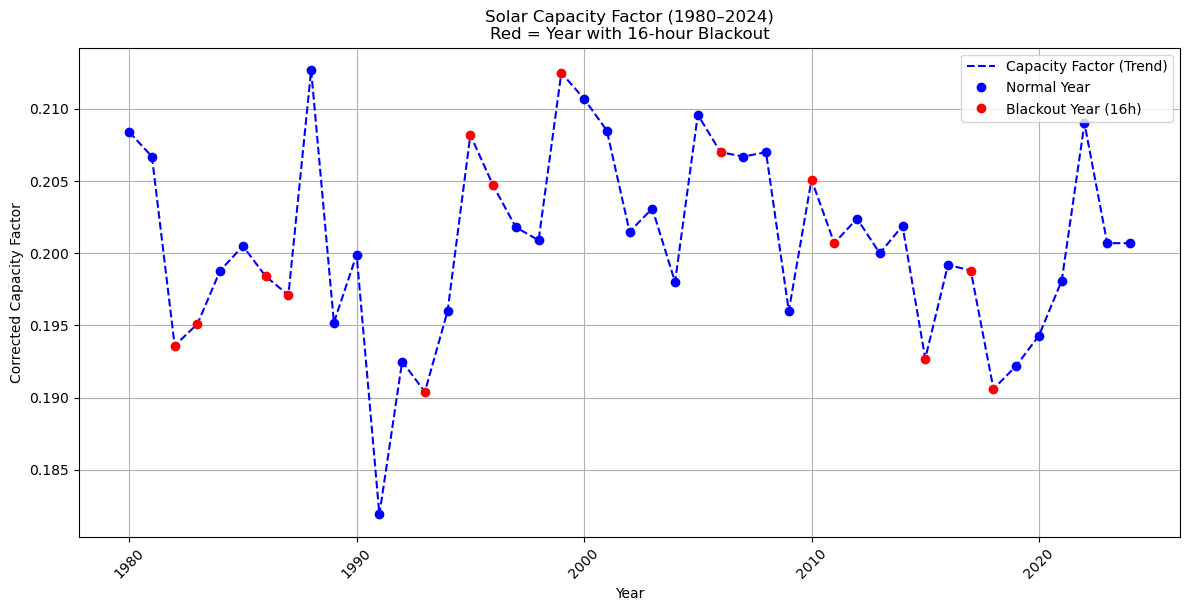


📈 Capacity Factor Vector (1980–2024):

[0.2084, 0.2067, 0.1936, 0.1951, 0.1988, 0.2005, 0.1984, 0.1971, 0.2127, 0.1952, 0.1999, 0.1819, 0.1925, 0.1904, 0.196, 0.2082, 0.2047, 0.2018, 0.2009, 0.2125, 0.2107, 0.2085, 0.2015, 0.2031, 0.198, 0.2096, 0.207, 0.2067, 0.207, 0.196, 0.2051, 0.2007, 0.2024, 0.2, 0.2019, 0.1927, 0.1992, 0.1988, 0.1906, 0.1922, 0.1943, 0.1981, 0.209, 0.2007, 0.2007]

🔴 Years with 16-hour blackout:
 [1982, 1983, 1986, 1987, 1993, 1995, 1996, 1999, 2006, 2010, 2011, 2015, 2017, 2018]


In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from collections import Counter

# === CONFIGURATION ===
dir_1980s = 'Desktop/Solar/1900s/'
dir_2000s = 'Desktop/Solar/2000s/'
panel_max_output_kw = 0.295
file_prefix = "ninja_pv_35.1460_-90.0518_uncorrected"

# === FUNCTIONS ===
def count_zero_streaks(electricity_series):
    streaks = []
    current_streak = 0
    for val in electricity_series:
        if val == 0:
            current_streak += 1
        elif current_streak > 0:
            streaks.append(current_streak)
            current_streak = 0
    if current_streak > 0:
        streaks.append(current_streak)
    return Counter(streaks)

def process_folder(data_dir, year_fn):
    results = []
    blackout_years = set()
    for filename in sorted(os.listdir(data_dir)):
        if filename.endswith('.csv') and '(' in filename and ')' in filename:
            try:
                idx = int(filename.split('(')[-1].split(')')[0])
                year = year_fn(idx)
                filepath = os.path.join(data_dir, filename)
                df = pd.read_csv(filepath, skiprows=3)

                if 'electricity' not in df.columns:
                    continue

                # Capacity Factor
                raw_mean_cf = df['electricity'].mean()
                corrected_cf = raw_mean_cf / panel_max_output_kw
                results.append((year, round(corrected_cf, 4)))

                # Blackout check
                streaks = count_zero_streaks(df['electricity'])
                if 16 in streaks:
                    blackout_years.add(year)

            except Exception as e:
                print(f"Error in {filename}: {e}")
    return results, blackout_years

# === Extract and Combine ===
cf_1980s, blackout_1980s = process_folder(dir_1980s, lambda idx: 1900 + idx)
cf_2000s, blackout_2000s = process_folder(dir_2000s, lambda idx: 2024 - idx)
all_cf = sorted(cf_1980s + cf_2000s, key=lambda x: x[0])
blackout_years = blackout_1980s.union(blackout_2000s)

# === Convert to DataFrame ===
df_cf = pd.DataFrame(all_cf, columns=['Year', 'Corrected_CF'])
df_cf['Blackout16'] = df_cf['Year'].isin(blackout_years)

# === Plot ===
plt.figure(figsize=(12, 6))

# Line plot
plt.plot(df_cf['Year'], df_cf['Corrected_CF'], linestyle='--', color='blue', label='Capacity Factor (Trend)')

# Points
for _, row in df_cf.iterrows():
    if row['Blackout16']:
        plt.plot(row['Year'], row['Corrected_CF'], 'o', color='red', label='Blackout Year (16h)')
    else:
        plt.plot(row['Year'], row['Corrected_CF'], 'o', color='blue', label='Normal Year')

# === Fix legend to avoid duplicates ===
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))  # Remove duplicates
plt.legend(by_label.values(), by_label.keys())

# === Labels and Formatting ===
plt.title('Solar Capacity Factor (1980–2024)\nRed = Year with 16-hour Blackout')
plt.xlabel('Year')
plt.ylabel('Corrected Capacity Factor')
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

# === Output Data ===
cf_vector = df_cf['Corrected_CF'].tolist()
print("\n📈 Capacity Factor Vector (1980–2024):\n")
print(cf_vector)

print("\n🔴 Years with 16-hour blackout:\n", sorted(blackout_years))


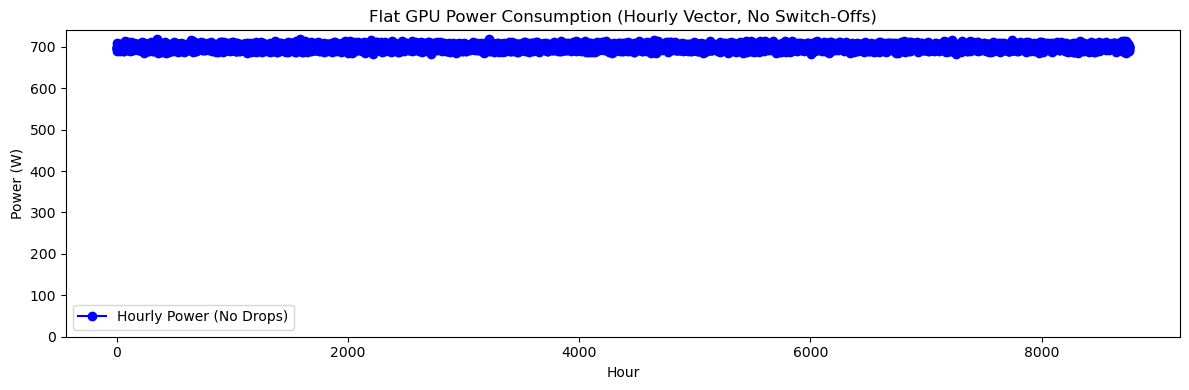

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the CSV
df_base = pd.read_csv('Desktop/base_power_profile.csv')


# Extract the 'Power_W' column as a NumPy array
base_power = df_base['Power_W'].to_numpy()
hours = np.arange(len(base_power))
# Optional: check first few values


plt.figure(figsize=(12, 4))
plt.plot(hours, base_power, marker='o', linestyle='-', color='blue', label='Hourly Power (No Drops)')
plt.title('Flat GPU Power Consumption (Hourly Vector, No Switch-Offs)')
plt.xlabel('Hour')
plt.ylabel('Power (W)')
plt.ylim(0, max(base_power) + 20)
#plt.grid(True)
#plt.xticks(hours)
plt.legend()
plt.tight_layout()
plt.show()



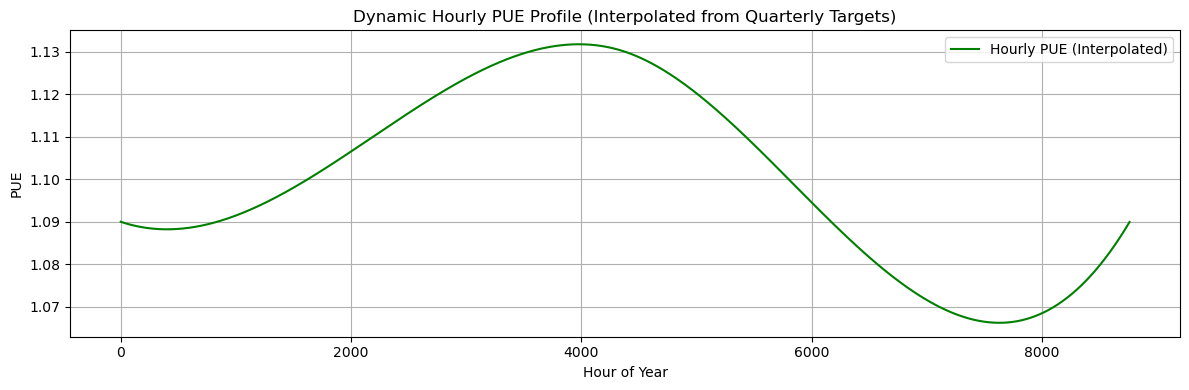

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# Total hours in a year
hours = 8760

# Define midpoints of each quarter (including start and end of year)
quarter_midpoints = np.linspace(0, hours, 5)  # [0, 2190, 4380, 6570, 8760]

# Target PUE values for each quarter
pue_targets = [1.09, 1.11, 1.13, 1.08, 1.09]  # Match quarter_midpoints

# Create a cubic spline interpolation
spline = make_interp_spline(quarter_midpoints, pue_targets, k=3)

# Generate hourly PUE values using the spline
hourly_pue = spline(np.arange(hours))

# Plot
plt.figure(figsize=(12, 4))
plt.plot(np.arange(hours), hourly_pue, label='Hourly PUE (Interpolated)', color='green')
plt.title('Dynamic Hourly PUE Profile (Interpolated from Quarterly Targets)')
plt.xlabel('Hour of Year')
plt.ylabel('PUE')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


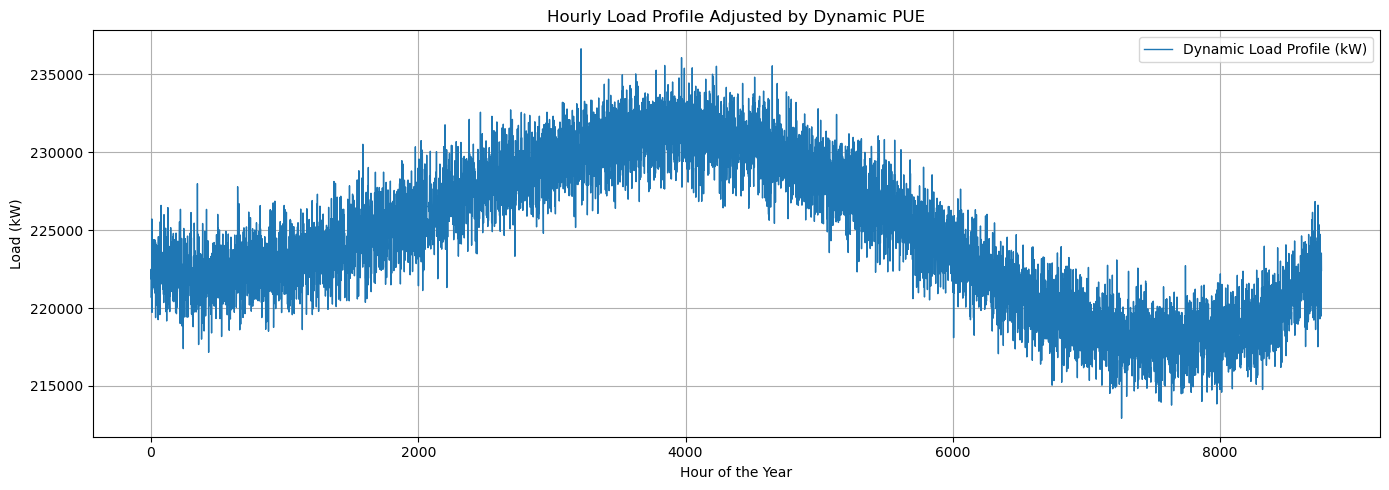

In [7]:
import pandas as pd
import numpy as np
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

from scipy.interpolate import make_interp_spline

# Generate hourly dynamic PUE profile
quarter_midpoints = np.linspace(0, hours, 5)  # [0, 2190, 4380, 6570, 8760]
pue_targets = [1.09, 1.11, 1.13, 1.08, 1.09]  # Quarterly values
spline = make_interp_spline(quarter_midpoints, pue_targets, k=3)
hourly_pue = spline(np.arange(hours))

# Load the CSV
df_base = pd.read_csv('Desktop/base_power_profile.csv')

# Extract the 'Power_W' column as a NumPy array
base_power = df_base['Power_W'].to_numpy()
hours = 8760
dc_ac_conversion_efficiency=0.963 #from eltek data center inverters white paper
#PUE= 1.15 #
load_profile = (base_power[:hours] / 1000) * 200000 * 1.405 * (hourly_pue / dc_ac_conversion_efficiency)  # kW

plt.figure(figsize=(14, 5))
plt.plot(np.arange(hours), load_profile, label="Dynamic Load Profile (kW)", linewidth=1)
plt.title("Hourly Load Profile Adjusted by Dynamic PUE")
plt.xlabel("Hour of the Year")
plt.ylabel("Load (kW)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


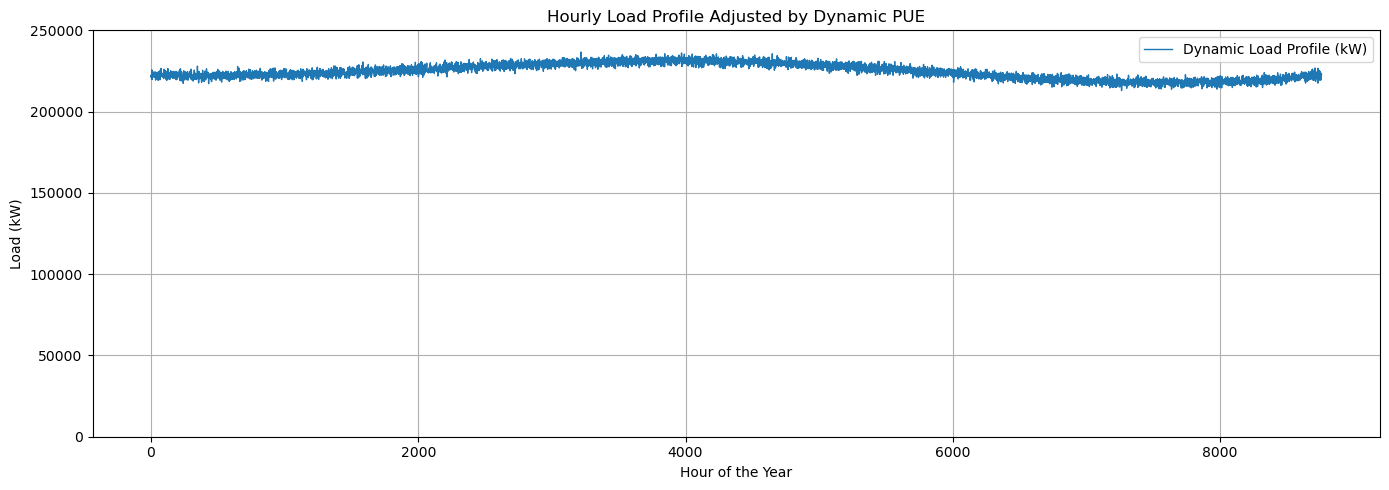

1968145395.613015

In [1]:
import pandas as pd
import numpy as np
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

from scipy.interpolate import make_interp_spline
hours = 8760
# Generate hourly dynamic PUE profile
quarter_midpoints = np.linspace(0, hours, 5)  # [0, 2190, 4380, 6570, 8760]
pue_targets = [1.09, 1.11, 1.13, 1.08, 1.09]  # Quarterly values
spline = make_interp_spline(quarter_midpoints, pue_targets, k=3)
hourly_pue = spline(np.arange(hours))

# Load the CSV
df_base = pd.read_csv('Desktop/base_power_profile.csv')

# Extract the 'Power_W' column as a NumPy array
base_power = df_base['Power_W'].to_numpy()

dc_ac_conversion_efficiency=0.963 #from eltek data center inverters white paper
#PUE= 1.15 #
load_profile = (base_power[:hours] / 1000) * 200000 * 1.405 * (hourly_pue / dc_ac_conversion_efficiency)  # kW

plt.figure(figsize=(14, 5))
plt.plot(np.arange(hours), load_profile, label="Dynamic Load Profile (kW)", linewidth=1)
plt.title("Hourly Load Profile Adjusted by Dynamic PUE")
plt.xlabel("Hour of the Year")
plt.ylabel("Load (kW)")
plt.ylim(0,250000)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
np.sum(load_profile)

<>:13: SyntaxWarning: invalid escape sequence '\c'
<>:13: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Abdullah\AppData\Local\Temp\ipykernel_29348\1134210903.py:13: SyntaxWarning: invalid escape sequence '\c'
  plt.title('Plot of $0.000144 \cdot DoD^{1.79}$')


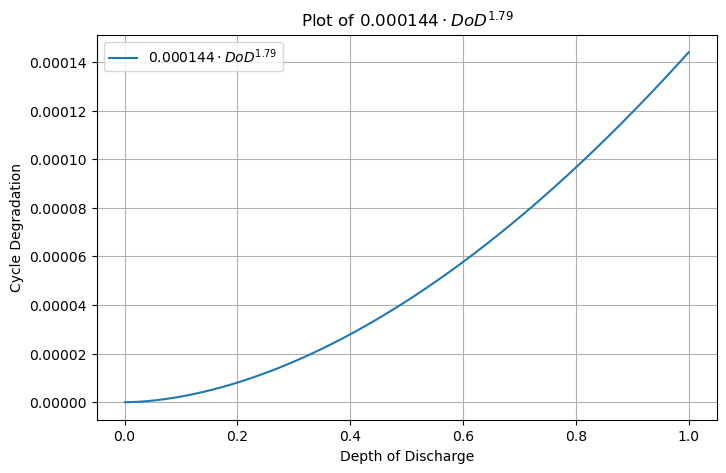

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Define x from 0 to 1 (avoid exact zero to prevent numerical issues)
x = np.linspace(0.001, 1, 500)
y = 0.000144 * x**1.79

# Plot
plt.figure(figsize=(8, 5))
plt.plot(x, y, label=r'$0.000144 \cdot DoD^{1.79}$')
plt.xlabel('Depth of Discharge')
plt.ylabel('Cycle Degradation')
plt.title('Plot of $0.000144 \cdot DoD^{1.79}$')
plt.grid(True)
plt.legend()
plt.show()


In [11]:
import numpy as np
required_uptime = 0.99
R_s = 0.99677
R_w = 0.994769
R_b = 0.99664
R_i = 0.997265

Ns_min = np.ceil(np.log(1 - required_uptime) / np.log(1 - R_s) * 1e5) / 1e5
Nw_min = np.ceil(np.log(1 - required_uptime) / np.log(1 - R_w) * 1e5) / 1e5
Nb_min = np.ceil(np.log(1 - required_uptime) / np.log(1 - R_b) * 1e5) / 1e5
Ni_min = np.ceil(np.log(1 - required_uptime) / np.log(1 - R_i) * 1e5) / 1e5

print(F" Solar Redundancy Factor is {Ns_min} for Colossus")
print(F" Wind Redundancy Factor is {Nw_min} for Colossus")
print(F" Battery Redundancy Factor is {Nb_min} for Colossus")
print(F" Inverter Redundancy Factor is {Ni_min} for Colossus")

 Solar Redundancy Factor is 0.80296 for Colossus
 Wind Redundancy Factor is 0.87665 for Colossus
 Battery Redundancy Factor is 0.80852 for Colossus
 Inverter Redundancy Factor is 0.78033 for Colossus


In [3]:
import numpy as np
required_uptime = 0.99671
R_s = 0.99677
R_w = 0.994769
R_b = 0.99664
R_i = 0.997265

Ns_min = np.ceil(np.log(1 - required_uptime) / np.log(1 - R_s) * 1e5) / 1e5
Nw_min = np.ceil(np.log(1 - required_uptime) / np.log(1 - R_w) * 1e5) / 1e5
Nb_min = np.ceil(np.log(1 - required_uptime) / np.log(1 - R_b) * 1e5) / 1e5
Ni_min = np.ceil(np.log(1 - required_uptime) / np.log(1 - R_i) * 1e5) / 1e5

print(F" Solar Redundancy Factor is {Ns_min} for Tier I")
print(F" Wind Redundancy Factor is {Nw_min} for Tier I")
print(F" Battery Redundancy Factor is {Nb_min} for Tier I")
print(F" Inverter Redundancy Factor is {Ni_min} for Tier I")

 Solar Redundancy Factor is 0.9968 for Tier I
 Wind Redundancy Factor is 1.08828 for Tier I
 Battery Redundancy Factor is 1.0037 for Tier I
 Inverter Redundancy Factor is 0.9687 for Tier I


In [5]:
required_uptime = 0.99749
R_s = 0.99677
R_w = 0.994769
R_b = 0.99664
R_i = 0.997265

Ns_min = np.ceil(np.log(1 - required_uptime) / np.log(1 - R_s) * 1e5) / 1e5
Nw_min = np.ceil(np.log(1 - required_uptime) / np.log(1 - R_w) * 1e5) / 1e5
Nb_min = np.ceil(np.log(1 - required_uptime) / np.log(1 - R_b) * 1e5) / 1e5
Ni_min = np.ceil(np.log(1 - required_uptime) / np.log(1 - R_i) * 1e5) / 1e5

print(F" Solar Redundancy Factor is {Ns_min} for Tier II")
print(F" Wind Redundancy Factor is {Nw_min} for Tier II")
print(F" Battery Redundancy Factor is {Nb_min} for Tier II")
print(F" Inverter Redundancy Factor is {Ni_min} for Tier II")

 Solar Redundancy Factor is 1.04398 for Tier II
 Wind Redundancy Factor is 1.13979 for Tier II
 Battery Redundancy Factor is 1.05121 for Tier II
 Inverter Redundancy Factor is 1.01455 for Tier II


In [7]:
required_uptime = 0.99982
R_s = 0.99677
R_w = 0.994769
R_b = 0.99664
R_i = 0.997265

Ns_min = np.ceil(np.log(1 - required_uptime) / np.log(1 - R_s) * 1e5) / 1e5
Nw_min = np.ceil(np.log(1 - required_uptime) / np.log(1 - R_w) * 1e5) / 1e5
Nb_min = np.ceil(np.log(1 - required_uptime) / np.log(1 - R_b) * 1e5) / 1e5
Ni_min = np.ceil(np.log(1 - required_uptime) / np.log(1 - R_i) * 1e5) / 1e5

print(F" Solar Redundancy Factor is {Ns_min} for Tier III")
print(F" Wind Redundancy Factor is {Nw_min} for Tier III")
print(F" Battery Redundancy Factor is {Nb_min} for Tier III")
print(F" Inverter Redundancy Factor is {Ni_min} for Tier III")

 Solar Redundancy Factor is 1.50343 for Tier III
 Wind Redundancy Factor is 1.64141 for Tier III
 Battery Redundancy Factor is 1.51385 for Tier III
 Inverter Redundancy Factor is 1.46105 for Tier III


In [9]:
required_uptime = 0.99995
R_s = 0.99677
R_w = 0.994769
R_b = 0.99664
R_i = 0.997265

Ns_min = np.ceil(np.log(1 - required_uptime) / np.log(1 - R_s) * 1e5) / 1e5
Nw_min = np.ceil(np.log(1 - required_uptime) / np.log(1 - R_w) * 1e5) / 1e5
Nb_min = np.ceil(np.log(1 - required_uptime) / np.log(1 - R_b) * 1e5) / 1e5
Ni_min = np.ceil(np.log(1 - required_uptime) / np.log(1 - R_i) * 1e5) / 1e5

print(F" Solar Redundancy Factor is {Ns_min} for Tier IV")
print(F" Wind Redundancy Factor is {Nw_min} for Tier IV")
print(F" Battery Redundancy Factor is {Nb_min} for Tier IV")
print(F" Inverter Redundancy Factor is {Ni_min} for Tier IV")

 Solar Redundancy Factor is 1.72677 for Tier IV
 Wind Redundancy Factor is 1.88525 for Tier IV
 Battery Redundancy Factor is 1.73874 for Tier IV
 Inverter Redundancy Factor is 1.6781 for Tier IV


Enter available GPU power as a percentage of 250W (e.g., 85):  17


Estimated training time extension factor: 1.785× baseline


Show graph? (y/n):  y


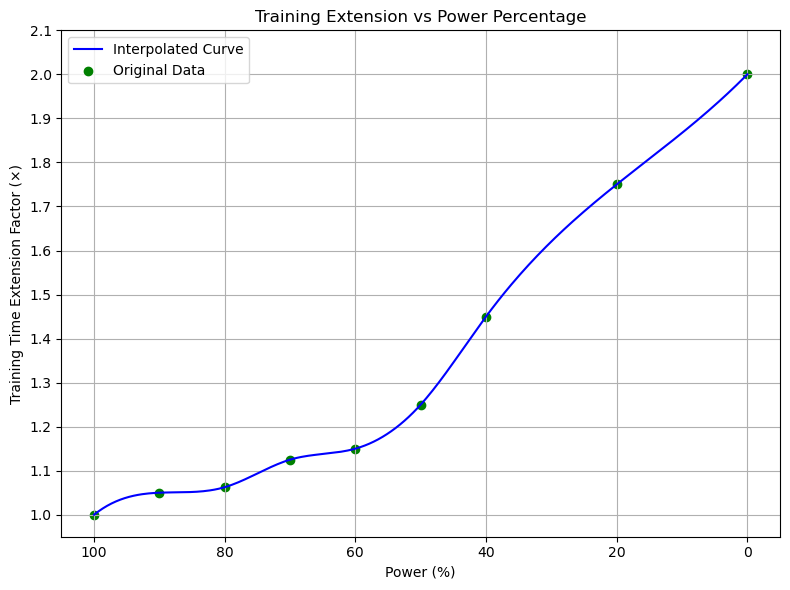

In [31]:
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# === Original Data ===
power_watts = np.array([250, 225, 200, 175, 150, 125, 100,50,0])
training_times = np.array([40000, 42000, 42500, 45000, 46000, 50000, 58000,70000,80000])
baseline_time = training_times[0]
extension_factors = training_times / baseline_time
power_missing_fraction = (250 - power_watts) / 250  # (1 - power%)

# === Interpolation Setup ===
interpolator = interp1d(power_missing_fraction, extension_factors, kind='cubic', fill_value='extrapolate')

# === Query Function ===
def get_training_extension(power_percent):
    if power_percent > 100 or power_percent < 0:
        return "Power % must be between 0 and 100."
    missing_fraction = 1 - (power_percent / 100)
    return interpolator(missing_fraction)

# === Example ===
# Try it with your own percentage here:
user_input = float(input("Enter available GPU power as a percentage of 250W (e.g., 85): "))
extension = get_training_extension(user_input)
print(f"Estimated training time extension factor: {extension:.3f}× baseline")

# === Optional: Show Plot ===
show_plot = input("Show graph? (y/n): ").strip().lower()
if show_plot == 'y':
    fine_missing_pct = np.linspace(0, 1, 300)
    fine_extension = interpolator(fine_missing_pct)
    fine_power_percent = 100 * (1 - fine_missing_pct)

    plt.figure(figsize=(8, 6))
    plt.plot(fine_power_percent, fine_extension, '-', color='blue', label='Interpolated Curve')
    plt.scatter(100 * (power_watts / 250), extension_factors, color='green', label='Original Data')
    #plt.scatter([100], [1.0], color='red', marker='^', s=100, label='Baseline (100%)')
    plt.xlabel('Power (%)')
    plt.yticks(np.arange(1.0, plt.ylim()[1] + 0.1, 0.1))
    plt.ylabel('Training Time Extension Factor (×)')
    plt.title('Training Extension vs Power Percentage')
    plt.gca().invert_xaxis()
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


Total Annual Energy Cost: $204,844,361.84


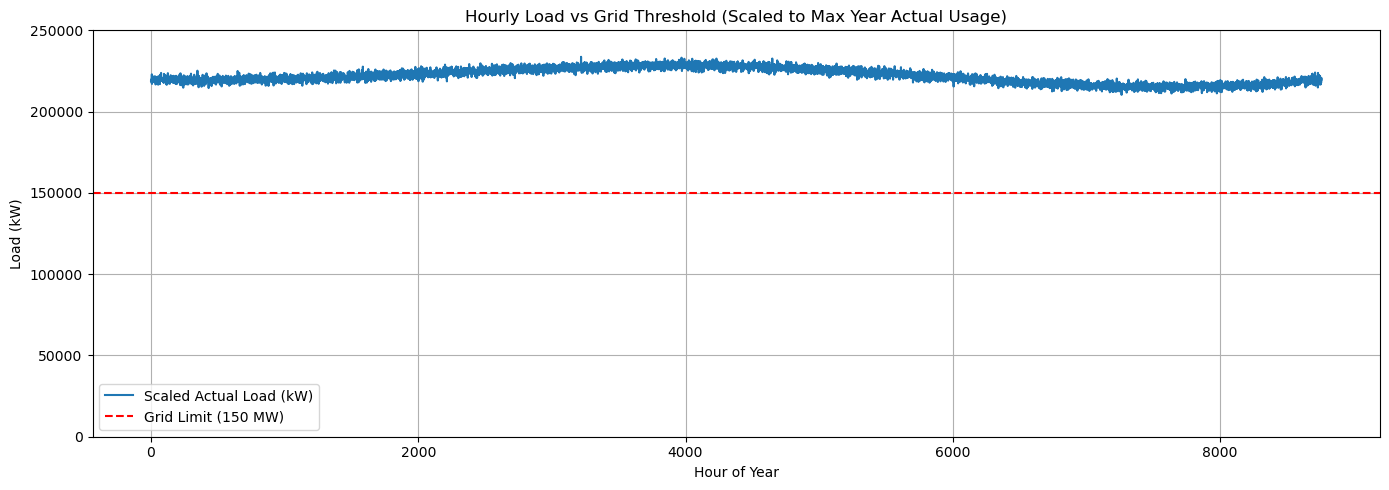

In [50]:
import pandas as pd
import numpy as np
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

from scipy.interpolate import make_interp_spline
hours = 8760
# Generate hourly dynamic PUE profile
quarter_midpoints = np.linspace(0, hours, 5)  # [0, 2190, 4380, 6570, 8760]
pue_targets = [1.09, 1.11, 1.13, 1.08, 1.09]  # Quarterly values
spline = make_interp_spline(quarter_midpoints, pue_targets, k=3)
hourly_pue = spline(np.arange(hours))

# Load the CSV
df_base = pd.read_csv('Desktop/base_power_profile.csv')

# Extract the 'Power_W' column as a NumPy array
base_power = df_base['Power_W'].to_numpy()

dc_ac_conversion_efficiency=0.975 #from eltek data center inverters white paper
#PUE= 1.15 #
load_profile = (base_power[:hours] / 1000) * 200000 * 1.405 * (hourly_pue / dc_ac_conversion_efficiency)  # kW
# Pricing in $/kWh
grid_limit_kw = 150000  # 150 MW
grid_rate = 0.072       # $/kWh
gas_rate = 0.175        # $/kWh

# Initialize cost array
hourly_cost = np.zeros_like(load_profile)

# Compute cost per hour
for i in range(hours):
    if load_profile[i] <= grid_limit_kw:
        hourly_cost[i] = load_profile[i] * grid_rate
    else:
        grid_energy = grid_limit_kw * grid_rate
        gas_energy = (load_profile[i] - grid_limit_kw) * gas_rate
        hourly_cost[i] = grid_energy + gas_energy

# Total cost for the year
total_annual_cost = np.sum(hourly_cost)

print(f"Total Annual Energy Cost: ${total_annual_cost:,.2f}")

# === Optional Plot ===
plt.figure(figsize=(14, 5))
plt.plot(load_profile, label="Scaled Actual Load (kW)")
plt.axhline(grid_limit_kw, color='red', linestyle='--', label="Grid Limit (150 MW)")
plt.xlabel("Hour of Year")
plt.ylim(0,250000)
plt.ylabel("Load (kW)")
plt.title("Hourly Load vs Grid Threshold (Scaled to Max Year Actual Usage)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


=== Net Present Cost (NPC) Statistics ===
Minimum NPC: $4,949,872,078.36
Maximum NPC: $5,013,447,956.89
Average NPC: $4,985,863,863.63


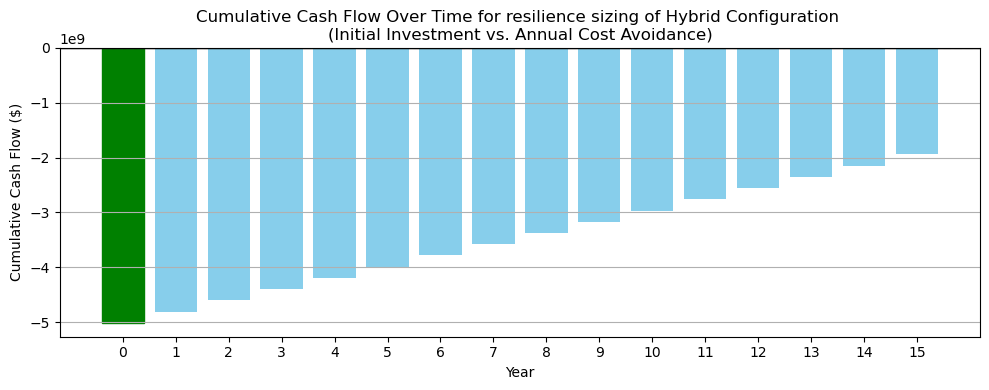

In [16]:
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
import os

# === File path configuration ===
file_path = r"C:\Users\Abdullah\Desktop\Furtheredit CSVs\dispatch_outputs_solar-wind_dc\capacity_and_costs_by_year.csv"

# === Check if the file exists ===
if not os.path.exists(file_path):
    raise FileNotFoundError(f"The file does not exist: {file_path}")

# === Load the CSV ===
df = pd.read_csv(file_path)

# === Check if 'Total_NPC' column exists ===
if 'Total_NPC' not in df.columns:
    raise ValueError("The column 'Total_NPC' was not found in the CSV.")

# === Calculate NPC statistics ===
min_npc = df['Total_NPC'].min()
max_npc = df['Total_NPC'].max()
avg_npc = df['Total_NPC'].mean()

# === Print results ===
print("=== Net Present Cost (NPC) Statistics ===")
print(f"Minimum NPC: ${min_npc:,.2f}")
print(f"Maximum NPC: ${max_npc:,.2f}")
print(f"Average NPC: ${avg_npc:,.2f}")


# Constants
project_lifetime = 15
annual_cost_avoided = total_annual_cost
investment = max_npc
#investment = 4_989_512_449.57

# Net cash flow: Year 0 has negative investment, followed by positive annual savings
cash_flows = [-investment] + [annual_cost_avoided] * project_lifetime
cumulative_cash_flow = np.cumsum(cash_flows)

# Plotting
plt.figure(figsize=(10, 4))
bars = plt.bar(range(project_lifetime + 1), cumulative_cash_flow, color='skyblue')
plt.axhline(0, color='black', linewidth=1)
plt.axhline(y=0, linestyle='--', color='gray')

# Highlight break-even year
break_even_year = np.argmax(cumulative_cash_flow >= 0)
bars[break_even_year].set_color('green')

# Labels and title
plt.title('Cumulative Cash Flow Over Time for resilience sizing of Hybrid Configuration \n(Initial Investment vs. Annual Cost Avoidance)')
plt.xlabel('Year')
plt.ylabel('Cumulative Cash Flow ($)')
plt.xticks(range(project_lifetime + 1))
plt.grid(axis='y')

# Annotate break-even year
#plt.text(break_even_year, cumulative_cash_flow[break_even_year], 
      #   f'  Break-even Year: {break_even_year}', color='green', va='bottom')

plt.tight_layout()
plt.show()


# Financial Costs

Total Annual Energy Cost: $198,040,634.60


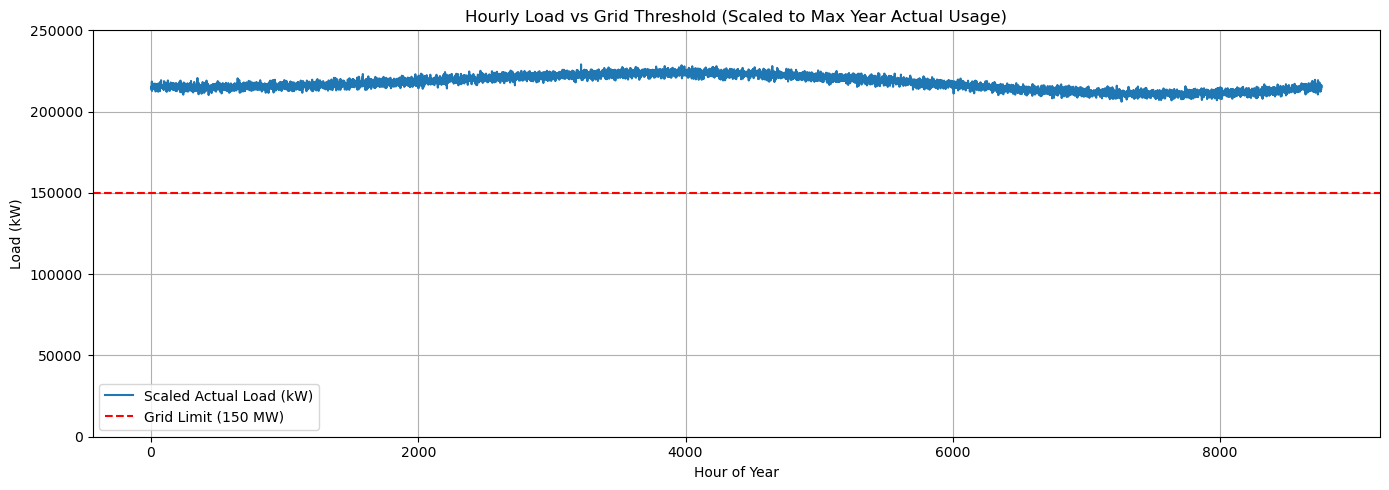

In [52]:
import pandas as pd
import numpy as np
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

from scipy.interpolate import make_interp_spline
hours = 8760
# Generate hourly dynamic PUE profile
quarter_midpoints = np.linspace(0, hours, 5)  # [0, 2190, 4380, 6570, 8760]
pue_targets = [1.09, 1.11, 1.13, 1.08, 1.09]  # Quarterly values
spline = make_interp_spline(quarter_midpoints, pue_targets, k=3)
hourly_pue = spline(np.arange(hours))

# Load the CSV
df_base = pd.read_csv('Desktop/base_power_profile.csv')

# Extract the 'Power_W' column as a NumPy array
base_power = df_base['Power_W'].to_numpy()

dc_ac_conversion_efficiency=0.975 
#PUE= 1.15 #
load_profile = 0.98*(base_power[:hours] / 1000) * 200000 * 1.405 * (hourly_pue / dc_ac_conversion_efficiency)  # kW
# Pricing in $/kWh
grid_limit_kw = 150000  # 150 MW
grid_rate = 0.072       # $/kWh
gas_rate = 0.175        # $/kWh

# Initialize cost array
hourly_cost = np.zeros_like(load_profile)

# Compute cost per hour
for i in range(hours):
    if load_profile[i] <= grid_limit_kw:
        hourly_cost[i] = load_profile[i] * grid_rate
    else:
        grid_energy = grid_limit_kw * grid_rate
        gas_energy = (load_profile[i] - grid_limit_kw) * gas_rate
        hourly_cost[i] = grid_energy + gas_energy

# Total cost for the year
total_annual_cost_financial = np.sum(hourly_cost)

print(f"Total Annual Energy Cost: ${total_annual_cost_financial:,.2f}")

# === Optional Plot ===
plt.figure(figsize=(14, 5))
plt.plot(load_profile, label="Scaled Actual Load (kW)")
plt.axhline(grid_limit_kw, color='red', linestyle='--', label="Grid Limit (150 MW)")
plt.xlabel("Hour of Year")
plt.ylim(0,250000)
plt.ylabel("Load (kW)")
plt.title("Hourly Load vs Grid Threshold (Scaled to Max Year Actual Usage)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


=== Net Present Cost (NPC) Statistics ===
Minimum NPC: $3,534,032,510.15
Maximum NPC: $3,599,690,829.52
Average NPC: $3,570,928,581.47


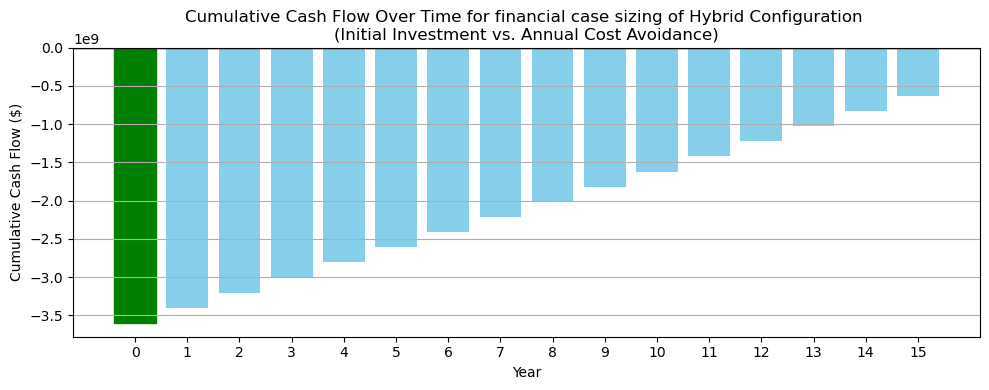

In [14]:

import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
import os

# === File path configuration ===
file_path = r"C:\Users\Abdullah\Desktop\Furtheredit CSVs\dispatch_outputs_solar-wind_dc_98metLoadCostCurtailment\capacity_and_costs_by_year.csv"

# === Check if the file exists ===
if not os.path.exists(file_path):
    raise FileNotFoundError(f"The file does not exist: {file_path}")

# === Load the CSV ===
df = pd.read_csv(file_path)

# === Check if 'Total_NPC' column exists ===
if 'Total_NPC' not in df.columns:
    raise ValueError("The column 'Total_NPC' was not found in the CSV.")

# === Calculate NPC statistics ===
min_npc = df['Total_NPC'].min()
max_npc = df['Total_NPC'].max()
avg_npc = df['Total_NPC'].mean()

# === Print results ===
print("=== Net Present Cost (NPC) Statistics ===")
print(f"Minimum NPC: ${min_npc:,.2f}")
print(f"Maximum NPC: ${max_npc:,.2f}")
print(f"Average NPC: ${avg_npc:,.2f}")


# Constants
project_lifetime = 15
annual_cost_avoided = total_annual_cost_financial
#investment = 3576752238.55
investment = max_npc

# Net cash flow: Year 0 has negative investment, followed by positive annual savings
cash_flows = [-investment] + [annual_cost_avoided] * project_lifetime
cumulative_cash_flow = np.cumsum(cash_flows)

# Plotting
plt.figure(figsize=(10, 4))
bars = plt.bar(range(project_lifetime + 1), cumulative_cash_flow, color='skyblue')
plt.axhline(0, color='black', linewidth=1)
plt.axhline(y=0, linestyle='--', color='gray')

# Highlight break-even year
break_even_year = np.argmax(cumulative_cash_flow >= 0)
bars[break_even_year].set_color('green')

# Labels and title
plt.title('Cumulative Cash Flow Over Time for financial case sizing of Hybrid Configuration \n(Initial Investment vs. Annual Cost Avoidance)')
plt.xlabel('Year')
plt.ylabel('Cumulative Cash Flow ($)')
plt.xticks(range(project_lifetime + 1))
plt.grid(axis='y')

# Annotate break-even year
#plt.text(break_even_year, cumulative_cash_flow[break_even_year], 
      #   f'  Break-even Year: {break_even_year}', color='green', va='bottom')

plt.tight_layout()
plt.show()


In [15]:
import pandas as pd

# Set the path to your CSV file
file_path = r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc\dispatch_data_1998.csv"

# Load the CSV into a DataFrame
df = pd.read_csv(file_path)

# Count the number of hours with unmet load
unmet_load_hours = (df['Unmet (kW)'] > 0).sum()

print(f"Number of hours with unmet load: {unmet_load_hours}")


Number of hours with unmet load: 64


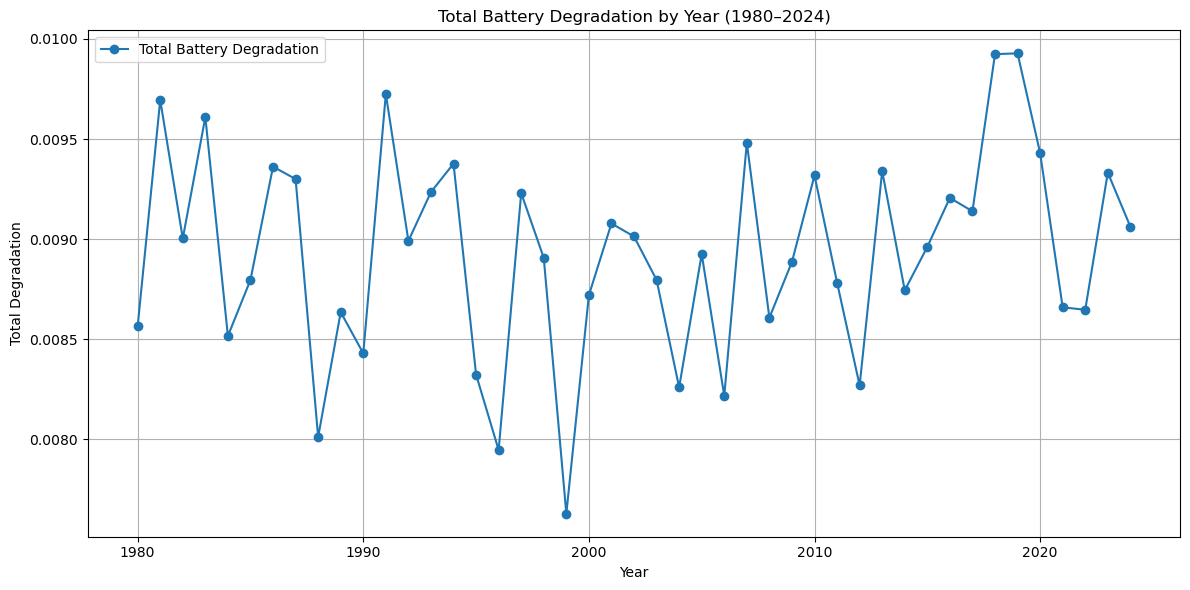


Average Annual Degradation (1980–2024): 0.008934


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === File Directory Configuration ===
folder_path = r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc"
years = list(range(2024, 1979, -1))

# === Store Total Degradation Per Year ===
yearly_degradation = {}

for year in years:
    file_path = os.path.join(folder_path, f"cycles_{year}.csv")
    try:
        df = pd.read_csv(file_path)
        if 'degradation' in df.columns:
            total_deg = df['degradation'].sum()
            yearly_degradation[year] = total_deg
        else:
            print(f"'degradation' column missing in {file_path}")
            yearly_degradation[year] = None
    except FileNotFoundError:
        print(f"File not found: {file_path}")
        yearly_degradation[year] = None

# === Plotting ===
years_sorted = sorted(yearly_degradation.keys())
degradation_values = [yearly_degradation[y] if yearly_degradation[y] is not None else 0 for y in years_sorted]

plt.figure(figsize=(12, 6))
plt.plot(years_sorted, degradation_values, marker='o', label='Total Battery Degradation')
plt.title("Total Battery Degradation by Year (1980–2024)")
plt.xlabel("Year")
plt.ylabel("Total Degradation")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

# === Average Degradation ===
valid_degs = [v for v in yearly_degradation.values() if v is not None]
avg_deg = np.mean(valid_degs)
print(f"\nAverage Annual Degradation (1980–2024): {avg_deg:.6f}")


In [7]:
import pandas as pd

# Path to your local file
file_path = r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc\cycles_2024.csv"

# Load and sum degradation
df = pd.read_csv(file_path)
total_degradation = df["degradation"].sum()

print(f"Total Battery Degradation in 2024: {total_degradation:.8f} ({total_degradation * 100:.2f}%)")


Total Battery Degradation in 2024: 0.00906200 (0.91%)


In [23]:
import pandas as pd

# Path to your local file
file_path = r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_80metLoadCostCurtailment\cycles_2005.csv"

# Load and sum degradation
df = pd.read_csv(file_path)
total_degradation = df["degradation"].sum()

print(f"Total Battery Degradation in 2024: {total_degradation:.8f} ({total_degradation * 100:.5f}%)")


Total Battery Degradation in 2024: 0.04195300 (4.19530%)


# Nevada 

Total Annual Energy Cost: $198,040,634.60


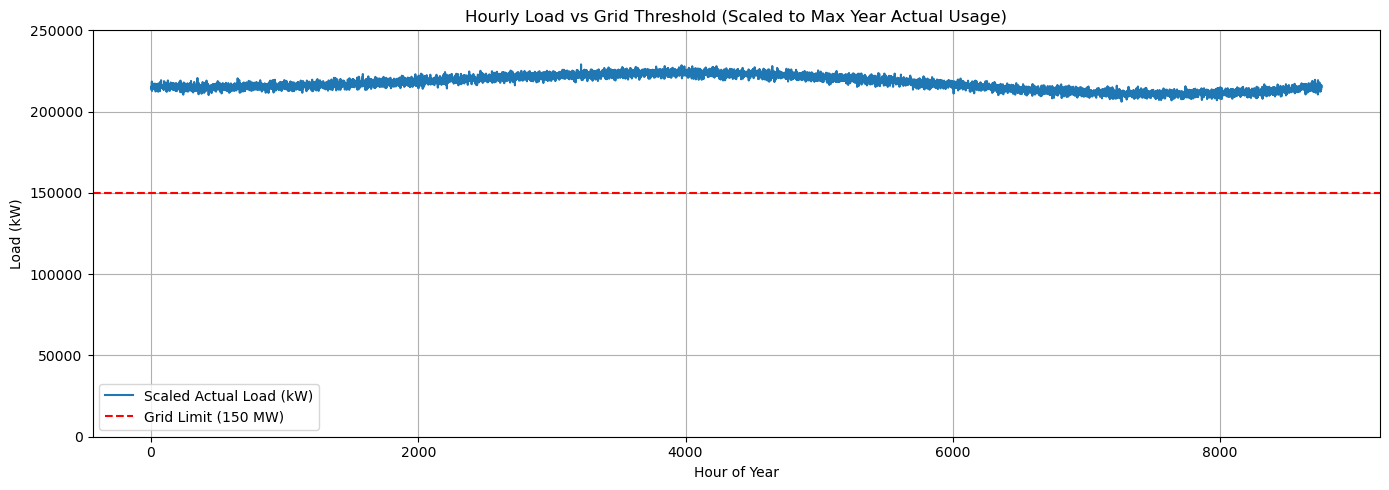

In [6]:
import pandas as pd
import numpy as np
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

from scipy.interpolate import make_interp_spline
hours = 8760
# Generate hourly dynamic PUE profile
quarter_midpoints = np.linspace(0, hours, 5)  # [0, 2190, 4380, 6570, 8760]
pue_targets = [1.09, 1.11, 1.13, 1.08, 1.09]  # Quarterly values
spline = make_interp_spline(quarter_midpoints, pue_targets, k=3)
hourly_pue = spline(np.arange(hours))

# Load the CSV
df_base = pd.read_csv('Desktop/base_power_profile.csv')

# Extract the 'Power_W' column as a NumPy array
base_power = df_base['Power_W'].to_numpy()

dc_ac_conversion_efficiency=0.975 
#PUE= 1.15 #
load_profile = 0.98*(base_power[:hours] / 1000) * 200000 * 1.405 * (hourly_pue / dc_ac_conversion_efficiency)  # kW
# Pricing in $/kWh
grid_limit_kw = 150000  # 150 MW
grid_rate = 0.072       # $/kWh
gas_rate = 0.175        # $/kWh

# Initialize cost array
hourly_cost = np.zeros_like(load_profile)

# Compute cost per hour
for i in range(hours):
    if load_profile[i] <= grid_limit_kw:
        hourly_cost[i] = load_profile[i] * grid_rate
    else:
        grid_energy = grid_limit_kw * grid_rate
        gas_energy = (load_profile[i] - grid_limit_kw) * gas_rate
        hourly_cost[i] = grid_energy + gas_energy

# Total cost for the year
total_annual_cost_financial = np.sum(hourly_cost)

print(f"Total Annual Energy Cost: ${total_annual_cost_financial:,.2f}")

# === Optional Plot ===
plt.figure(figsize=(14, 5))
plt.plot(load_profile, label="Scaled Actual Load (kW)")
plt.axhline(grid_limit_kw, color='red', linestyle='--', label="Grid Limit (150 MW)")
plt.xlabel("Hour of Year")
plt.ylim(0,250000)
plt.ylabel("Load (kW)")
plt.title("Hourly Load vs Grid Threshold (Scaled to Max Year Actual Usage)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


=== Net Present Cost (NPC) Statistics ===
Minimum NPC: $3,436,310,901.82
Maximum NPC: $3,528,341,742.81
Average NPC: $3,464,284,422.38


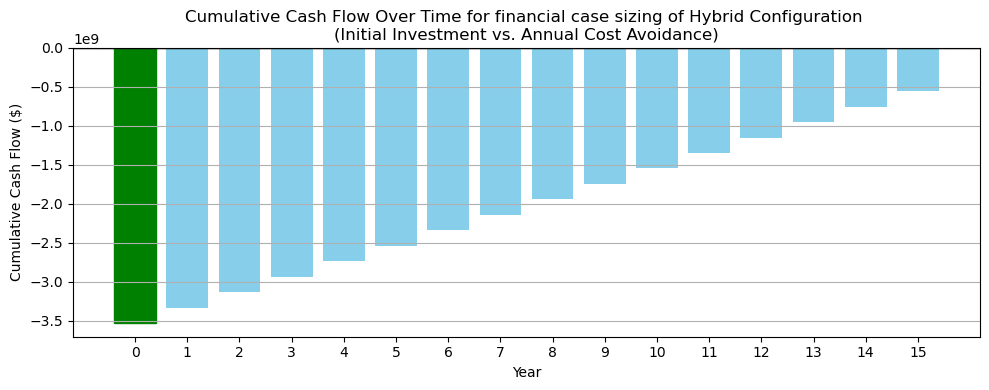

In [10]:

import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
import os

# === File path configuration ===
file_path = r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc_99metloadNevada\capacity_and_costs_by_year.csv"


# === Check if the file exists ===
if not os.path.exists(file_path):
    raise FileNotFoundError(f"The file does not exist: {file_path}")

# === Load the CSV ===
df = pd.read_csv(file_path)

# === Check if 'Total_NPC' column exists ===
if 'Total_NPC' not in df.columns:
    raise ValueError("The column 'Total_NPC' was not found in the CSV.")

# === Calculate NPC statistics ===
min_npc = df['Total_NPC'].min()
max_npc = df['Total_NPC'].max()
avg_npc = df['Total_NPC'].mean()

# === Print results ===
print("=== Net Present Cost (NPC) Statistics ===")
print(f"Minimum NPC: ${min_npc:,.2f}")
print(f"Maximum NPC: ${max_npc:,.2f}")
print(f"Average NPC: ${avg_npc:,.2f}")


# Constants
project_lifetime = 15
annual_cost_avoided = total_annual_cost_financial
#investment = 3576752238.55
investment = max_npc

# Net cash flow: Year 0 has negative investment, followed by positive annual savings
cash_flows = [-investment] + [annual_cost_avoided] * project_lifetime
cumulative_cash_flow = np.cumsum(cash_flows)

# Plotting
plt.figure(figsize=(10, 4))
bars = plt.bar(range(project_lifetime + 1), cumulative_cash_flow, color='skyblue')
plt.axhline(0, color='black', linewidth=1)
plt.axhline(y=0, linestyle='--', color='gray')

# Highlight break-even year
break_even_year = np.argmax(cumulative_cash_flow >= 0)
bars[break_even_year].set_color('green')

# Labels and title
plt.title('Cumulative Cash Flow Over Time for financial case sizing of Hybrid Configuration \n(Initial Investment vs. Annual Cost Avoidance)')
plt.xlabel('Year')
plt.ylabel('Cumulative Cash Flow ($)')
plt.xticks(range(project_lifetime + 1))
plt.grid(axis='y')

# Annotate break-even year
#plt.text(break_even_year, cumulative_cash_flow[break_even_year], 
      #   f'  Break-even Year: {break_even_year}', color='green', va='bottom')

plt.tight_layout()
plt.show()


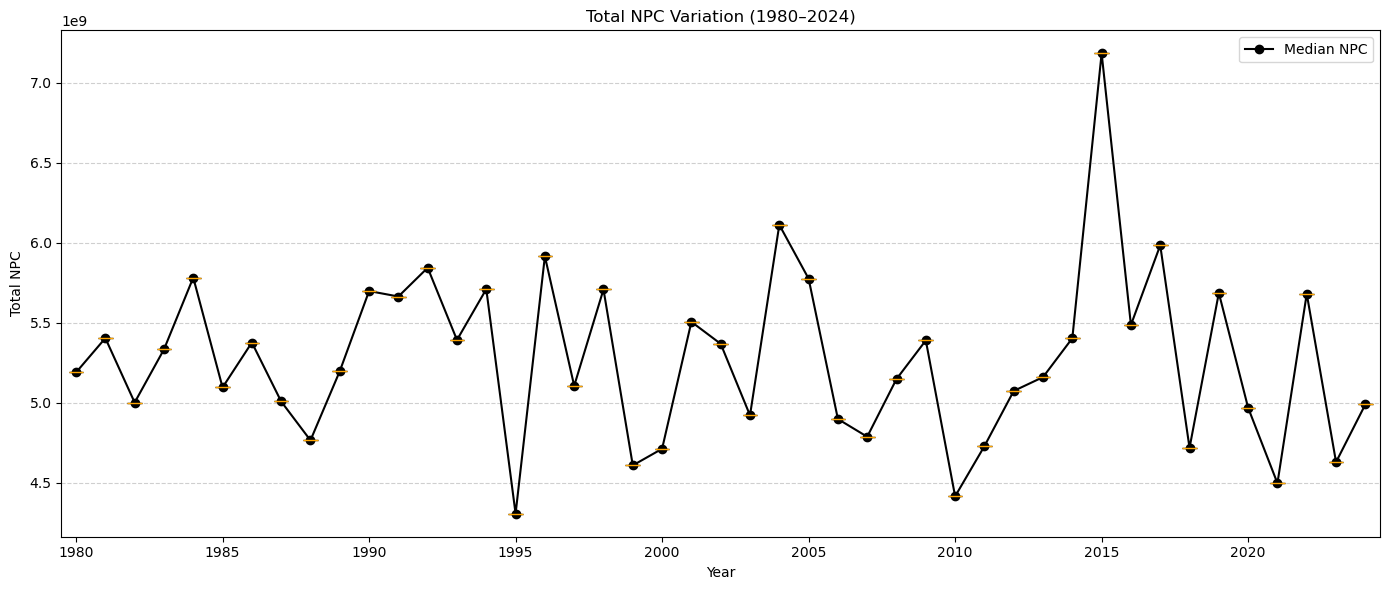

    Year  Median_Total_NPC
44  1980      5.189619e+09
43  1981      5.404154e+09
42  1982      5.001352e+09
41  1983      5.333487e+09
40  1984      5.782537e+09
39  1985      5.095702e+09
38  1986      5.376663e+09
37  1987      5.007879e+09
36  1988      4.764841e+09
35  1989      5.197290e+09
34  1990      5.698429e+09
33  1991      5.664387e+09
32  1992      5.844143e+09
31  1993      5.392650e+09
30  1994      5.710526e+09
29  1995      4.306029e+09
28  1996      5.915966e+09
27  1997      5.105637e+09
26  1998      5.708544e+09
25  1999      4.608166e+09
24  2000      4.712006e+09
23  2001      5.505949e+09
22  2002      5.368382e+09
21  2003      4.921117e+09
20  2004      6.112530e+09
19  2005      5.776070e+09
18  2006      4.898060e+09
17  2007      4.787372e+09
16  2008      5.148414e+09
15  2009      5.389737e+09
14  2010      4.414570e+09
13  2011      4.728516e+09
12  2012      5.073691e+09
11  2013      5.160199e+09
10  2014      5.403652e+09
9   2015      7.185035e+09
8

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === Folder naming pattern ===
base_folder = r"C:\Users\Abdullah\dispatch_outputs_solar-wind_dc"
folder_pattern = lambda year: base_folder if year == 2024 else base_folder + str(year)

# === Collect NPC values ===
years = list(range(2024, 1979, -1))
npc_data = []
npc_medians = []

for year in years:
    folder = folder_pattern(year)
    file_path = os.path.join(folder, "capacity_and_costs_by_year.csv")
    
    try:
        df = pd.read_csv(file_path)
        if 'Year' in df.columns:
            df = df[df['Year'] == year]
        npcs = df['Total_NPC'].tolist()
        npc_data.append(npcs)
        npc_medians.append(np.median(npcs))
    except Exception as e:
        print(f"Failed for {year}: {e}")
        npc_data.append([])
        npc_medians.append(np.nan)

# === Plot ===
plt.figure(figsize=(14, 6))

# Boxplot
plt.boxplot(npc_data, patch_artist=True,
            boxprops=dict(facecolor='skyblue'),
            medianprops=dict(color='orange'),
            showfliers=True)

# Line plot of medians
plt.plot(range(1, len(npc_medians)+1), npc_medians, color='black', linestyle='-', marker='o', label='Median NPC')

# === Custom x-axis ticks at 5-year intervals ===
tick_indices = [i+1 for i, y in enumerate(years) if y % 5 == 0]
tick_labels = [y for y in years if y % 5 == 0]

plt.xticks(ticks=tick_indices, labels=tick_labels)
plt.gca().invert_xaxis()  # Make x-axis go from 1980 to 2024 left to right

# Labels and formatting
plt.title("Total NPC Variation (1980–2024)")
plt.ylabel("Total NPC")
plt.xlabel("Year")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()
# Prepare a DataFrame to display year and corresponding median Total_NPC
median_npc_by_year = pd.DataFrame({
    'Year': years,
    'Median_Total_NPC': npc_medians
})

# Sort by ascending year for clearer output
median_npc_by_year_sorted = median_npc_by_year.sort_values(by='Year')

# Also return the DataFrame object
print(median_npc_by_year_sorted)
